# Clustering audio à partir des fichiers chroma

On utilise ici les features de Chordino qui permettent d'étudier les accords.

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import plotly.express as px
from plotly.offline import plot
import plotly.io as pio
from sklearn.manifold import MDS
import librosa
from scipy.cluster.hierarchy import linkage, dendrogram
import os
import importlib
from music21 import *
import oeuvre
importlib.reload(oeuvre)
from oeuvre import Oeuvre

In [107]:
dico_res = {"maj":[0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0],
"min":[0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0],
"dim_dim7":[0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0],
"dim_min7":[0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1,0],
"maj_min7":[0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0],
"maj_maj7":[0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,1],
"min_min7":[0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0],
"dim":[0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0],
"aug":[0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0]}

In [108]:
dico_notes = {
    "A" : 0,
    "A#" : 1,
    "Bb" : 1,
    "B" : 2,
    "B#" : 3,
    "C" : 3,
    "C#" : 4,
    "Db" : 4,
    "D" : 5,
    "D#" : 6,
    "Eb" : 6,
    "E" : 7,
    "E#" : 8,
    "F" : 8,
    "F#" : 9,
    "Gb" : 9,
    "G" : 10,
    "G#" : 11,
    "Ab" : 11,
    "N" : -1
}

In [109]:
dico_rec = {
    0 : "A",
    1: "A#",
    2: "B",
    3: "B#",
    4: "C#",
    5: "D",
    6: "D#",
    7: "E",
    8: "F",
    9: "F#",
    10: "G",
    11: "G#",
}

In [110]:
def quinte_dist_note(n1,n2):
    i = interval.Interval(note.Note(n1), note.Note(n2))
    k = 0
    while (7*k % 12 != i.semitones%12):
        k+=1
        #print(f"i = {i.semitones} et 7*k % 12 = {7*k % 12}")
        #print(f"Itération {k} pour {n1} et {n2}")
    return k

print(quinte_dist_note('C','F#'))
print(quinte_dist_note('Eb','Bb'))

6
1


In [111]:
def quinte_dist(i1,i2):
    n1 = dico_rec[i1]
    n2 = dico_rec[i2]
    return quinte_dist_note(n1,n2)

In [112]:
li_filenames = []

for racine, _, fichiers in os.walk('cross-era_chords-chordino'):
    for fichier in fichiers:
        chemin_relatif = os.path.relpath(os.path.join(racine, fichier))
        li_filenames.append(chemin_relatif)

## Récupération d'un fichier et transformation en features

In [113]:
def get_matrix(chunk):
    li = []
    i = -1
    tonalite = chunk[-1].split("_")[0]
    while tonalite == 'N':
        i -= 1
        tonalite = chunk[i].split("_")[0]
    ind_tonalite = dico_notes[tonalite]
    for accord in chunk:
        partition = accord.split("_")
        note = partition[0]
        if dico_notes[note] > 0:
            liste = [(dico_notes[note] - ind_tonalite)%12]
            acc = "_".join(partition[1:])
            liste += dico_res[acc]
            li.append(liste)
    return np.array(li).flatten()

In [114]:
def get_chunks(filename):
    data = pd.read_csv(filename, sep=",", header=None)
    chunks = {}
    chunk = []
    title = None
    for i, row in data.iterrows():
        if pd.notna(row[0]):
            if title is not None:
                chunks[title] = chunk
            title = row[0]
            chunk = []
        else:
            chunk.append(row[2])
    
    if title is not None:
        chunks[title] = chunk
    return chunks

def dico_chunks(filename):
    chunks = get_chunks(filename)
    return {k: get_matrix(v) for k, v in chunks.items() if len(v) > 0}

In [115]:
li = get_chunks(li_filenames[0])
morc = li['orchestra_addon/CrossEra-1601_Bach_CPE_sinfonia_in_a_major_wq._182_no._4.mp3']
print(morc)
get_matrix(morc)

['F#_maj', 'B_min', 'A_maj_maj7', 'D_maj', 'A_maj', 'A_aug', 'B_min', 'E_maj_maj7', 'C#_min', 'F#_maj_min7', 'B_maj', 'E_maj', 'A_min', 'B_maj_min7', 'C#_min_min7', 'C_maj_maj7', 'A_maj', 'E_maj', 'F#_maj', 'B_min', 'A_maj_maj7', 'D_maj', 'A_maj', 'A_aug', 'B_min', 'E_maj_maj7', 'C#_min', 'F#_maj_min7', 'B_maj', 'E_maj', 'A_min', 'B_maj_min7', 'C#_min_min7', 'C_maj_maj7', 'A_maj', 'E_maj', 'C#_maj', 'F#_min', 'A_dim_dim7', 'C#_min', 'Ab_maj', 'C#_min', 'Ab_maj', 'C#_min', 'A_maj_min7', 'D_maj_maj7', 'G_maj_maj7', 'E_maj_maj7', 'C#_dim', 'F#_min', 'D_maj', 'Ab_dim_min7', 'C#_min', 'F#_min_min7', 'B_min_min7', 'E_maj', 'A_maj', 'D_min', 'F#_min_min7', 'D_maj', 'E_maj', 'D_maj', 'A_maj', 'C#_maj', 'F#_min', 'A_dim_dim7', 'C#_min', 'Ab_maj', 'A_maj_maj7', 'Ab_maj', 'C#_min', 'A_maj_min7', 'D_maj_maj7', 'G_maj_maj7', 'Ab_min_min7', 'C#_min_min7', 'F#_min', 'A_maj_min7', 'D_maj', 'Ab_dim_min7', 'C#_min', 'F#_min_min7', 'B_min_min7', 'E_maj', 'A_maj', 'D_min', 'F#_min_min7', 'D_maj', 'E_maj',

array([9, 0, 0, ..., 0, 1, 0])

## Création des objets

In [116]:
def construct_oeuvre(name,matrix = None):
    oeuvre = Oeuvre(name)
    oeuvre.filename = name
    name = name[:-3]
    part1 = name.split("/")
    cat = part1[0].split("_")
    oeuvre.category = cat[0]
    oeuvre.genre = cat[1]
    part2 = part1[1].split("_")[1:]
    oeuvre.compositeur = part2[0]
    oeuvre.titre = " ".join(part2[1:])
    oeuvre.matrix = matrix
    return oeuvre

In [117]:
print(construct_oeuvre("piano_classical/CrossEra-1001_Cimarosa_Piano_sonata_no._10_in_b-flat_major___allegro.mp3"))


        Titre : Piano sonata no. 10 in b-flat major   allegro.
        Compositeur : Cimarosa
        Genre : classical
        Catégorie : piano
        Fichier d'origine : piano_classical/CrossEra-1001_Cimarosa_Piano_sonata_no._10_in_b-flat_major___allegro.mp3
        


In [118]:
def li_oeuvres(filename):
    dico = dico_chunks(filename)
    return [construct_oeuvre(k,v) for k,v in dico.items()]

def encyclo_oeuvres(filenames):
    li = []
    for filename in filenames:
        li += li_oeuvres(filename)
        print(f"{filename} fait")
    return li

In [119]:
liste_oeuvres = encyclo_oeuvres(li_filenames)

cross-era_chords-chordino\chords-chordino_orchestra_addon.csv fait
cross-era_chords-chordino\chords-chordino_orchestra_baroque.csv fait
cross-era_chords-chordino\chords-chordino_orchestra_classical.csv fait
cross-era_chords-chordino\chords-chordino_orchestra_modern.csv fait
cross-era_chords-chordino\chords-chordino_orchestra_romantic.csv fait
cross-era_chords-chordino\chords-chordino_piano_addon.csv fait
cross-era_chords-chordino\chords-chordino_piano_baroque.csv fait
cross-era_chords-chordino\chords-chordino_piano_classical.csv fait
cross-era_chords-chordino\chords-chordino_piano_modern.csv fait
cross-era_chords-chordino\chords-chordino_piano_romantic.csv fait


## Clustering

In [154]:
def distance(mat1,mat2, dec, alpha = 1):
    d1 = mat1[0]
    d2 = mat2[0]
    dist1 = quinte_dist(d1,d2)
    dist2 = np.mean((mat1[1:] - mat2[dec+1:dec+len(mat1)])**2)
    return alpha*dist1 + (1-alpha)*dist2

def distance_oeuvres(oeuvre1,oeuvre2, alpha = 1):
    mat1 = oeuvre1.matrix
    mat2 = oeuvre2.matrix
    if len(mat1)<=len(mat2):
        m1 = mat1
        m2 = mat2
    else:
        m1 = mat2
        m2 = mat1
    return min([distance(m1,m2,dec,alpha) for dec in range(len(m2)-len(m1)+1)])

In [155]:
import random

liste_oeuvres_sel = random.sample(liste_oeuvres, 30)

In [177]:
alpha = 0.1
dist = np.zeros((len(liste_oeuvres_sel),len(liste_oeuvres_sel)), dtype = float)

for (i,mat1) in enumerate(liste_oeuvres_sel):
    for (j,mat2) in enumerate(liste_oeuvres_sel):
            if i < j:
                dist[i,j] = distance_oeuvres(mat1,mat2, alpha)
                dist[j,i] = dist[i,j]
            print(i,repr(mat1),j,repr(mat2), dist[i,j])


scaler = StandardScaler()
normalized_matrix = scaler.fit_transform(dist)

with open("distance_matrix2.pkl", "wb") as f:
    pickle.dump(dist, f)

kmeans = KMeans(n_clusters=5, random_state=42)  # Adjust n_clusters as needed
os.environ["OMP_NUM_THREADS"] = "1"
#clusters = kmeans.fit_predict(normalized_matrix)
clusters = kmeans.fit_predict(dist)

print(clusters)
first_cluster_oeuvres = [liste_oeuvres[i] for i in range(len(clusters)) if clusters[i] == 0]
print(first_cluster_oeuvres)

0 Mendelssohn - presto. - romantic 0 Mendelssohn - presto. - romantic 0.0
0 Mendelssohn - presto. - romantic 1 Mendelssohn - no003 02 vivace non troppo. - romantic 1.712354988399072
0 Mendelssohn - presto. - romantic 2 Bach - Brandenburg concerto no. 6 in b flat major bwv 1049 allegro. - baroque 0.7826118588577665
0 Mendelssohn - presto. - romantic 3 Bach - CPE sinfonia in b minor wq. 182 no. 5. - addon 1.6957482284285121
0 Mendelssohn - presto. - romantic 4 Brahms - no003 03 poco allegretto. - romantic 0.8160058202982903
0 Mendelssohn - presto. - romantic 5 Saintsaens - Sylvia le temple de diane final. - romantic 0.9177419354838711
0 Mendelssohn - presto. - romantic 6 Haydn - sonata no. 34 in d majoradagio. - classical 0.7075586095392078
0 Mendelssohn - presto. - romantic 7 Schumann - symphony no. 3 in e flat major rhenish op. 97- feierlich dir halben wie vorher die viertel. - romantic 0.8837759185158239
0 Mendelssohn - presto. - romantic 8 Platti - piano sonata no. 3 in f major op. 1

c:\Log_inst\Programmation-Anaconda\envs\MODAL\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



C:\Users\PCAJM\AppData\Local\Temp\ipykernel_10920\1457723588.py:4: ClusterWarning:

The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix



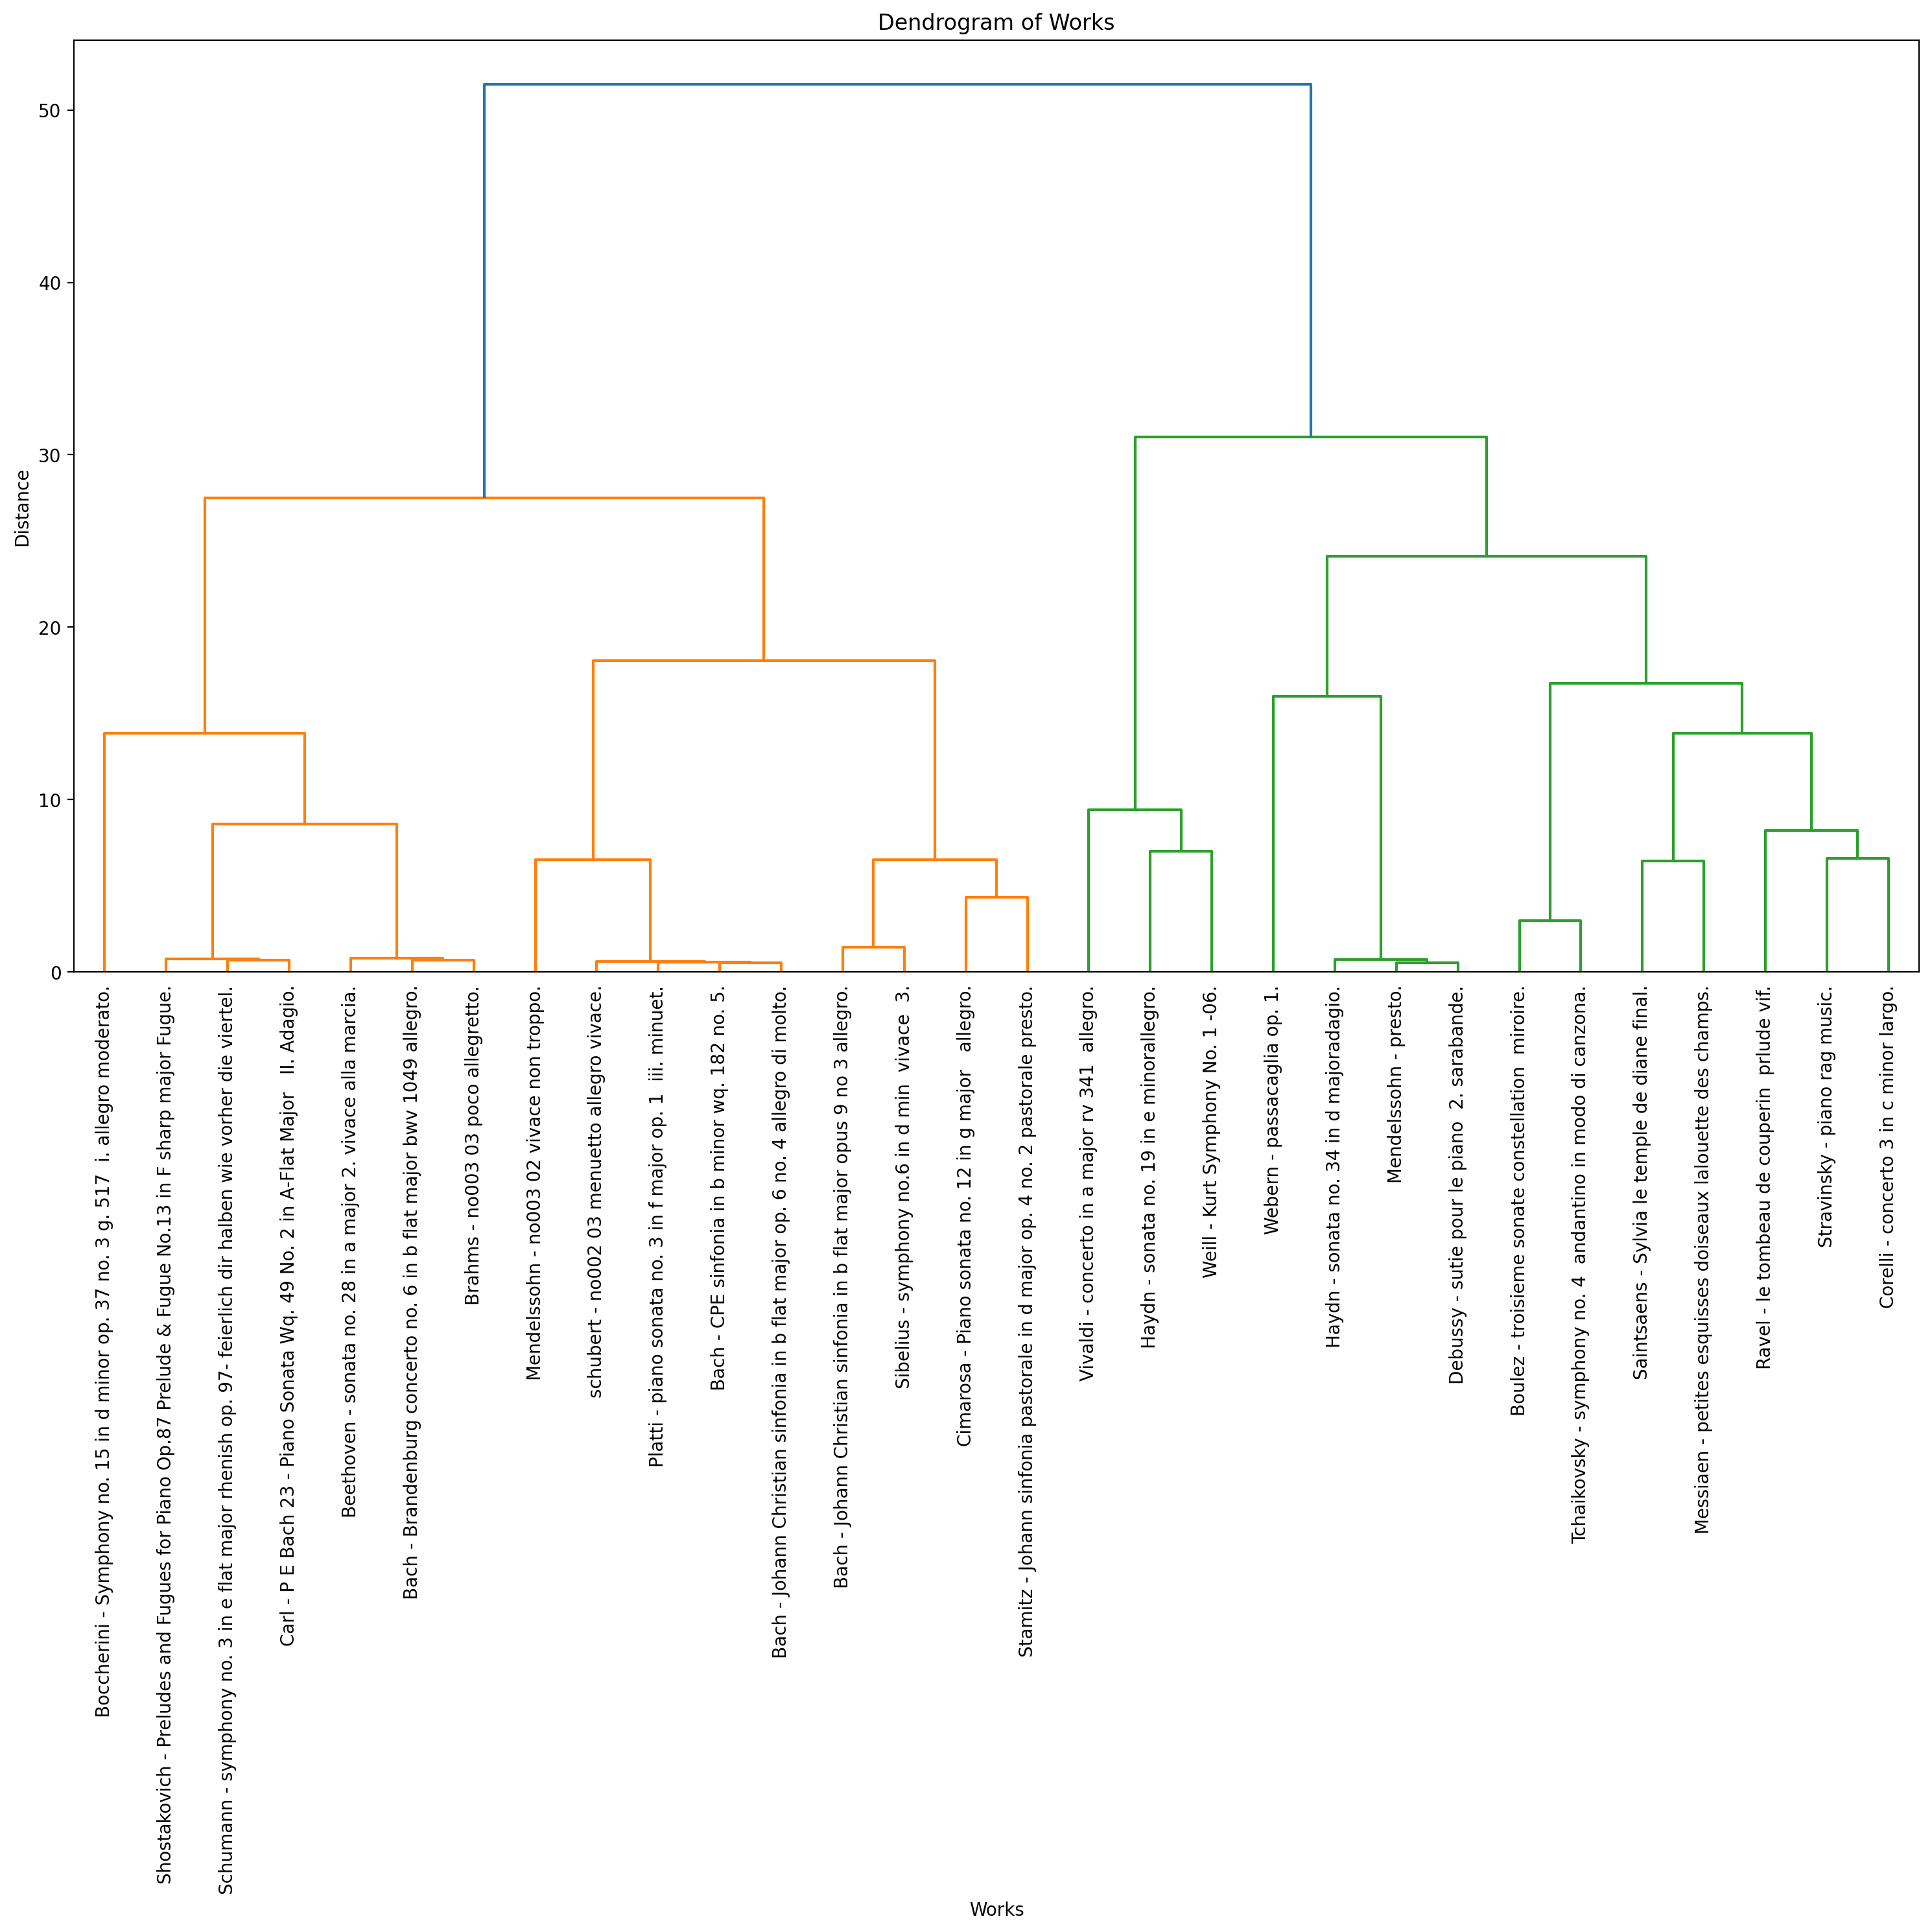

In [175]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Perform hierarchical clustering
linked = linkage(dist, method='ward')

# Create a list of labels for the x-axis (composer and title)
labels = [f"{oeuvre.compositeur} - {oeuvre.titre}" for oeuvre in liste_oeuvres_sel]

# Plot the dendrogram
plt.figure(figsize=(15, 15))
dendrogram(linked, labels=labels, leaf_rotation=90, leaf_font_size=10)
plt.title("Dendrogram of Works")
plt.xlabel("Works")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


In [172]:
print(clusters)

[0 1 2 1 2 4 0 2 1 1 2 0 0 4 3 0 4 2 2 1 3 2 4 1 3 1 0 1 1 4]


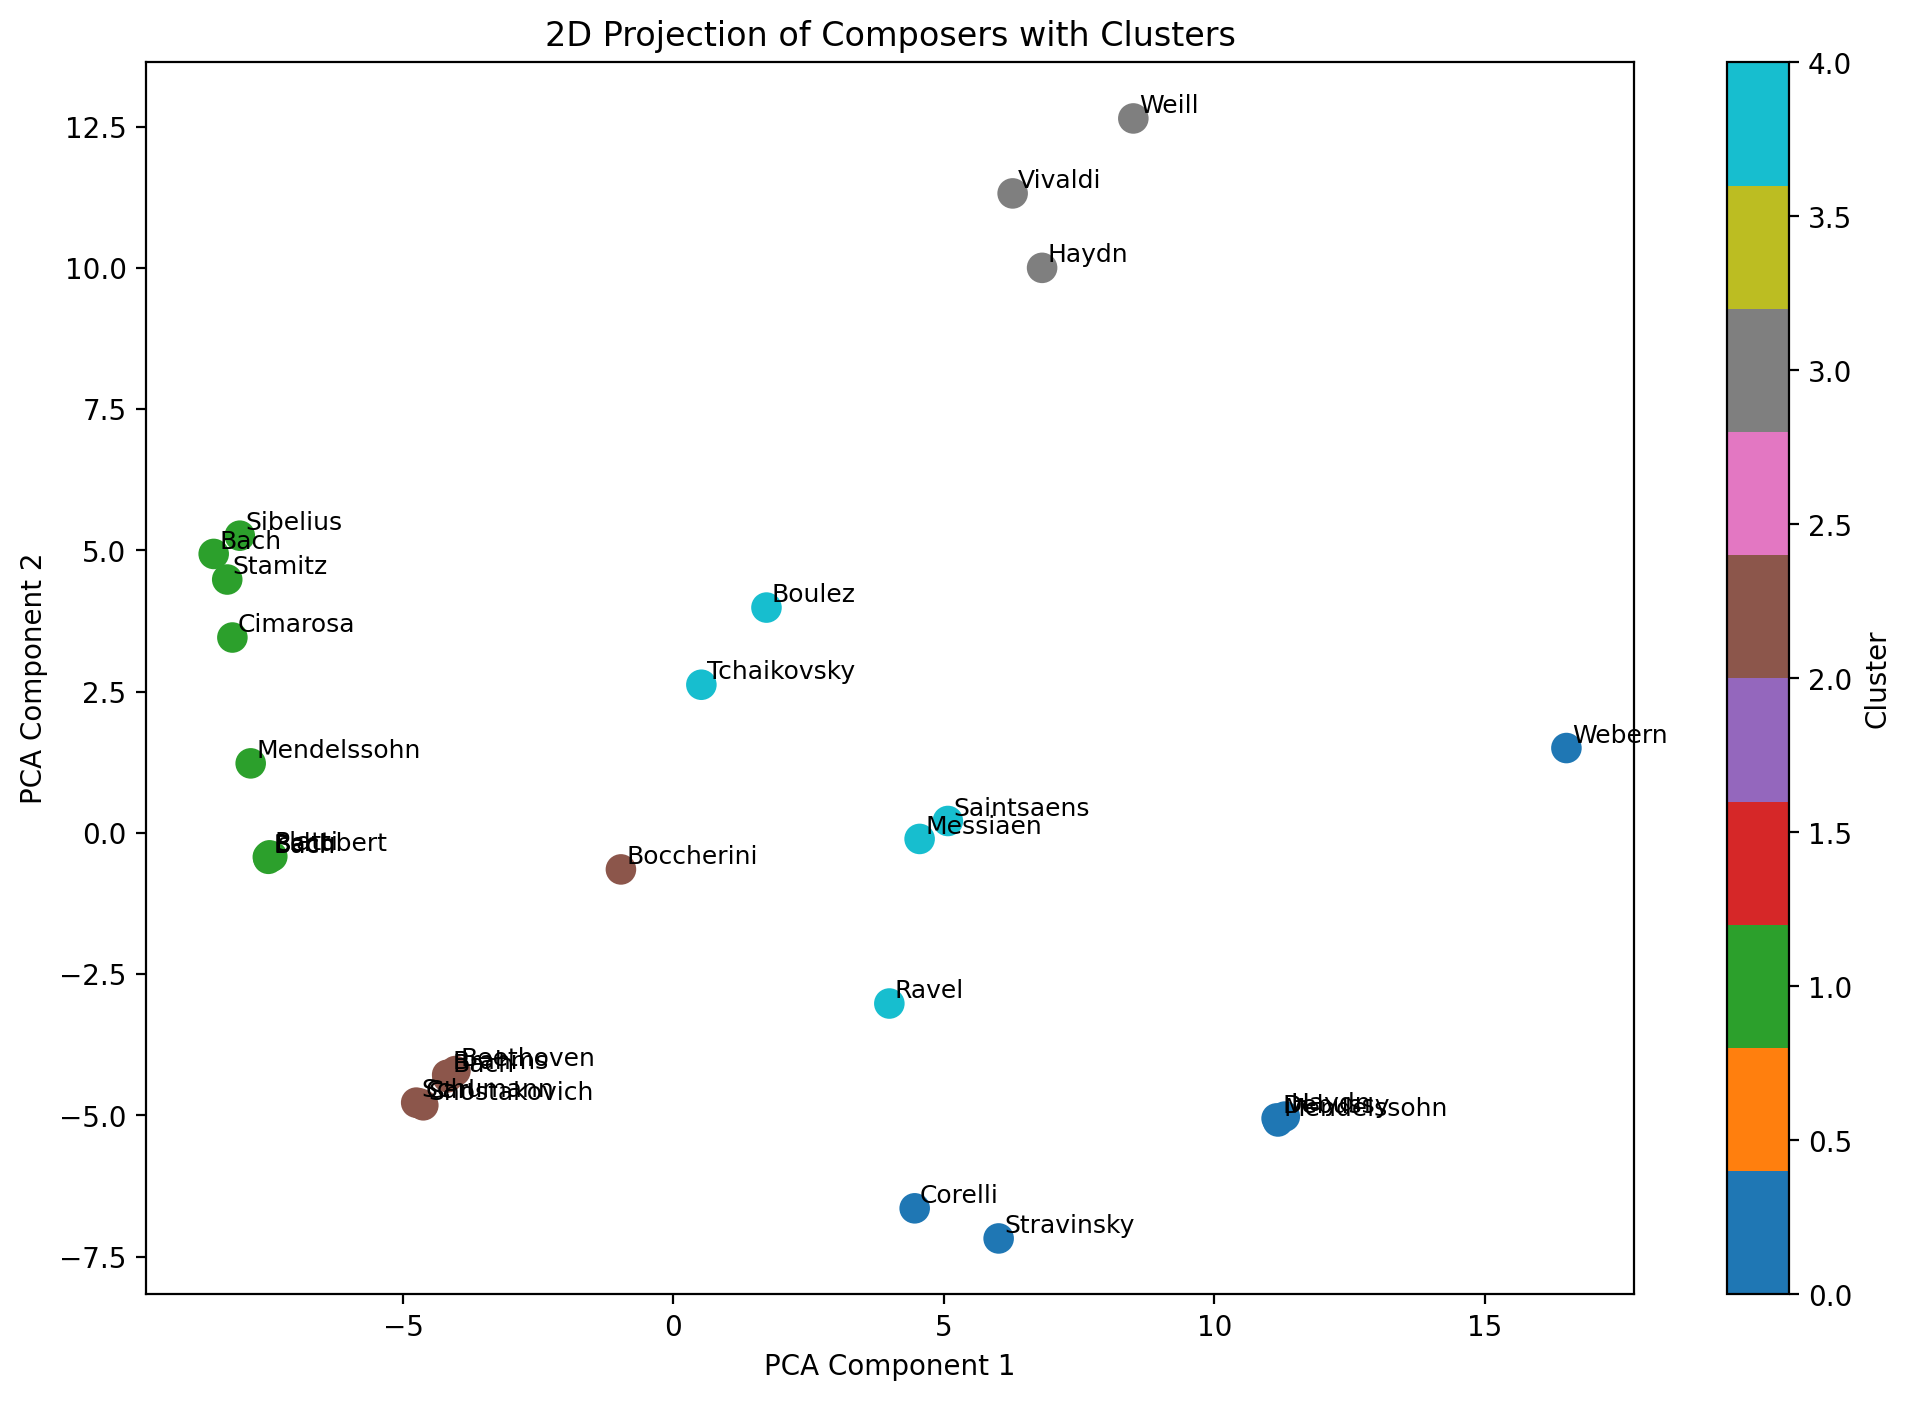

In [173]:
# Perform PCA to reduce dimensions to 2D
pca_2d = PCA(n_components=2)
points_2d = pca_2d.fit_transform(dist)

# Create a scatter plot
plt.figure(figsize=(12, 8))
scatter = plt.scatter(points_2d[:, 0], points_2d[:, 1], c=clusters, cmap='tab10', s=100)

list_compositeurs = [oeuvre.compositeur for oeuvre in liste_oeuvres_sel]

# Add annotations for each composer
for i, composer in enumerate(list_compositeurs):
    plt.text(points_2d[i, 0] + 0.1, points_2d[i, 1] + 0.1, composer, fontsize=9)

# Add a colorbar to indicate clusters
plt.colorbar(scatter, label="Cluster")

# Add labels and title
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("2D Projection of Composers with Clusters")

# Show the plot
plt.show()

In [170]:
# Create a DataFrame with composer, title, and cluster information
data = {
    "Composer": [oeuvre.compositeur for oeuvre in liste_oeuvres_sel],
    "Title": [oeuvre.titre for oeuvre in liste_oeuvres_sel],
    "Cluster": clusters
}

df_clusters = pd.DataFrame(data)

# Sort by cluster
sorted_clusters = df_clusters.sort_values(by="Cluster")

# Display the sorted DataFrame
print(sorted_clusters)

        Composer                                              Title  Cluster
0    Mendelssohn                                            presto.        0
5     Saintsaens                   Sylvia le temple de diane final.        0
6          Haydn                    sonata no. 34 in d majoradagio.        0
26       Corelli                       concerto 3 in c minor largo.        0
22      Messiaen   petites esquisses doiseaux lalouette des champs.        0
11       Debussy                 sutie pour le piano  2. sarabande.        0
12    Stravinsky                                   piano rag music.        0
16         Ravel                le tombeau de couperin  prlude vif.        0
15        Webern                                 passacaglia op. 1.        0
1    Mendelssohn                        no003 02 vivace non troppo.        1
23      schubert                  no002 03 menuetto allegro vivace.        1
3           Bach             CPE sinfonia in b minor wq. 182 no. 5.        1